In [ ]:
Title: Building 17 Energy Consumption Analysis
Objective: Compare energy consumption at 13:00 on March 20, 2023 vs. March 20, 2024.
Data Source: energy_readings table.

Connecting to database and fetching data...

 Building 17 @ 13:00 on 2023-03-20 → 2.61 kWh
 Building 17 @ 13:00 on 2024-03-20 → 2.44 kWh
 Difference: -0.17 kWh


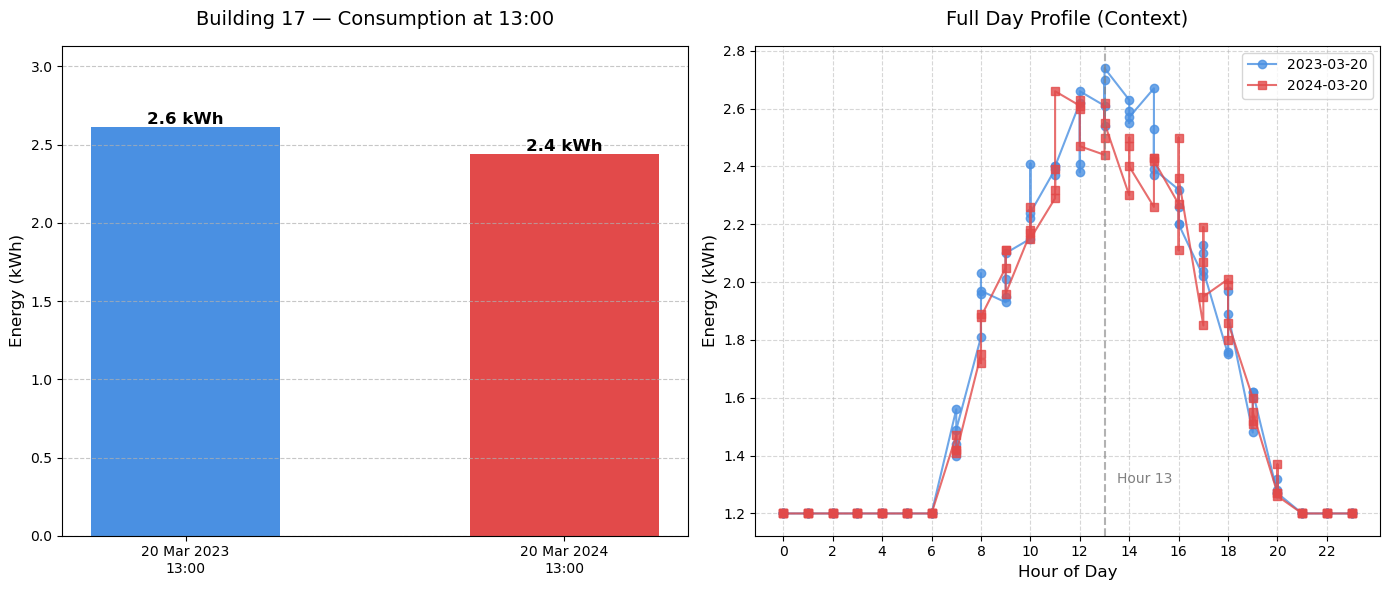

In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import urllib.parse

# ============================================================
# 1. DATABASE CONNECTION (PostgreSQL)
# ============================================================
# STEP 1: Fill in your PostgreSQL credentials
USER     = "postgres"
PASSWORD = "YOUR PASSWORD"
HOST     = "localhost"
PORT     = "5432"
DB_NAME  = "energy_intelligence_project1"

# STEP 2: Safely encode the password (handles special characters like @, #, $)
safe_password = urllib.parse.quote_plus(PASSWORD)

# STEP 3: Build the connection string
connection_string = (
    f"postgresql+psycopg2://{USER}:{safe_password}"
    f"@{HOST}:{PORT}/{DB_NAME}?client_encoding=utf8"
)

# STEP 4: Create the connection engine
engine = create_engine(connection_string)

# ============================================================
# 2. SQL QUERY
# ============================================================
query = """
SELECT 
    timestamp,
    energy_kwh
FROM 
    energy_readings
WHERE 
    building_id = 17
    AND (
        (timestamp >= '2023-03-20 00:00:00' AND timestamp < '2023-03-21 00:00:00')
        OR 
        (timestamp >= '2024-03-20 00:00:00' AND timestamp < '2024-03-21 00:00:00')
    )
ORDER BY timestamp;
"""

# ============================================================
# 3. LOAD DATA
# ============================================================
print("Connecting to database and fetching data...")
df = pd.read_sql(query, engine)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ============================================================
# 4. EXTRACT HOUR 13 FOR EACH DATE
# ============================================================
hour_13 = df[df['timestamp'].dt.hour == 13].copy()

try:
    val_2023 = hour_13[hour_13['timestamp'].dt.year == 2023]['energy_kwh'].iloc[0]
    val_2024 = hour_13[hour_13['timestamp'].dt.year == 2024]['energy_kwh'].iloc[0]

    print(f"\n Building 17 @ 13:00 on 2023-03-20 → {val_2023} kWh")
    print(f" Building 17 @ 13:00 on 2024-03-20 → {val_2024} kWh")
    print(f" Difference: {val_2024 - val_2023:+.2f} kWh")
except IndexError:
    print("\n No data found for Hour 13 on one or both dates.")
    val_2023, val_2024 = 0, 0

# ============================================================
# 5. VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------- Chart 1: Direct Comparison (Bar Chart) ----------
labels = ['20 Mar 2023\n13:00', '20 Mar 2024\n13:00']
values = [val_2023, val_2024]
colors = ['#4A90E2', '#E24A4A']

bars = axes[0].bar(labels, values, color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, height,
        f'{height:.1f} kWh',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

axes[0].set_title('Building 17 — Consumption at 13:00', fontsize=14, pad=15)
axes[0].set_ylabel('Energy (kWh)', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
if max(values) > 0:
    axes[0].set_ylim(0, max(values) * 1.2)

# ---------- Chart 2: Full Day Context (Line Chart) ----------
df_2023 = df[df['timestamp'].dt.year == 2023]
df_2024 = df[df['timestamp'].dt.year == 2024]

axes[1].plot(
    df_2023['timestamp'].dt.hour, df_2023['energy_kwh'],
    marker='o', label='2023-03-20', color='#4A90E2', alpha=0.8
)
axes[1].plot(
    df_2024['timestamp'].dt.hour, df_2024['energy_kwh'],
    marker='s', label='2024-03-20', color='#E24A4A', alpha=0.8
)

axes[1].axvline(x=13, color='gray', linestyle='--', alpha=0.6)
if max(values) > 0:
    axes[1].text(13.5, max(values) * 0.5, 'Hour 13', color='gray', fontsize=10)

axes[1].set_title('Full Day Profile (Context)', fontsize=14, pad=15)
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Energy (kWh)', fontsize=12)
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('building17_comparison.png', dpi=150)
plt.show()